In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/anime.csv')
def clean_genre_string(genre_str):
    if pd.isna(genre_str):
        return ''
    genres = genre_str.split(',')
    cleaned = []
    for g in genres:
        g = g.strip()
        half = len(g) // 2
        # If it's a doubled word like "DramaDrama", keep only the first half
        if len(g) % 2 == 0 and g[:half] == g[half:]:
            g = g[:half]
        cleaned.append(g)
    return ', '.join(cleaned)

df['Genres'] = df['Genres'].apply(clean_genre_string)
df['GenreList'] = df['Genres'].str.split(', ')

# Fill missing ratings with 0 and genres with "Unknown"
df['Score'] = df['Score'].fillna(0)
df['Genres'] = df['Genres'].fillna('Unknown')
# Convert episodes to numeric, turn non-numeric into NaN
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')

irrelevant_types = ['Avant Garde', 'Boys Love', 'Ecchi', 'Girls Love', 'Horror', 'Unknown','']
df = df[df['GenreList'].apply(lambda genres: not any(g in irrelevant_types for g in genres))]



# Visual 1 - Top 10 Animes Genres by Frequency

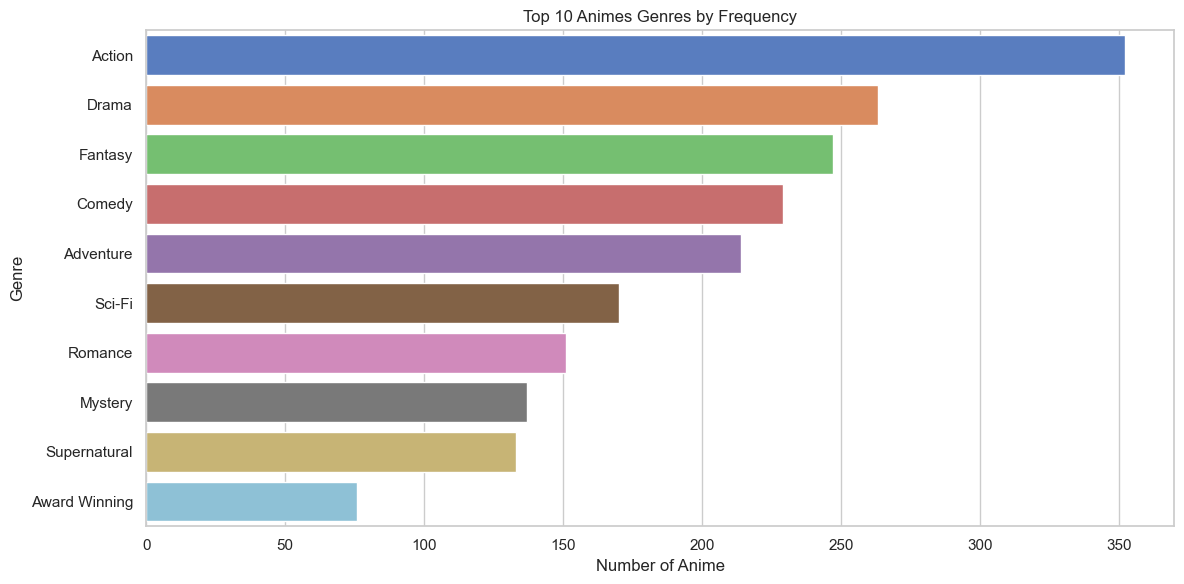

In [27]:
# Explode the GenreList column so each genre gets its own row
genre_counts = df.explode('GenreList')['GenreList'].value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.values[:10], y=genre_counts.index[:10],hue=genre_counts.index[:10], palette='muted', legend=False)
plt.title('Top 10 Animes Genres by Frequency')
plt.xlabel('Number of Anime')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('../visuals/top_10_genres.png')
plt.show()

# Visual 2 - Top 10 Genres by Average Rating

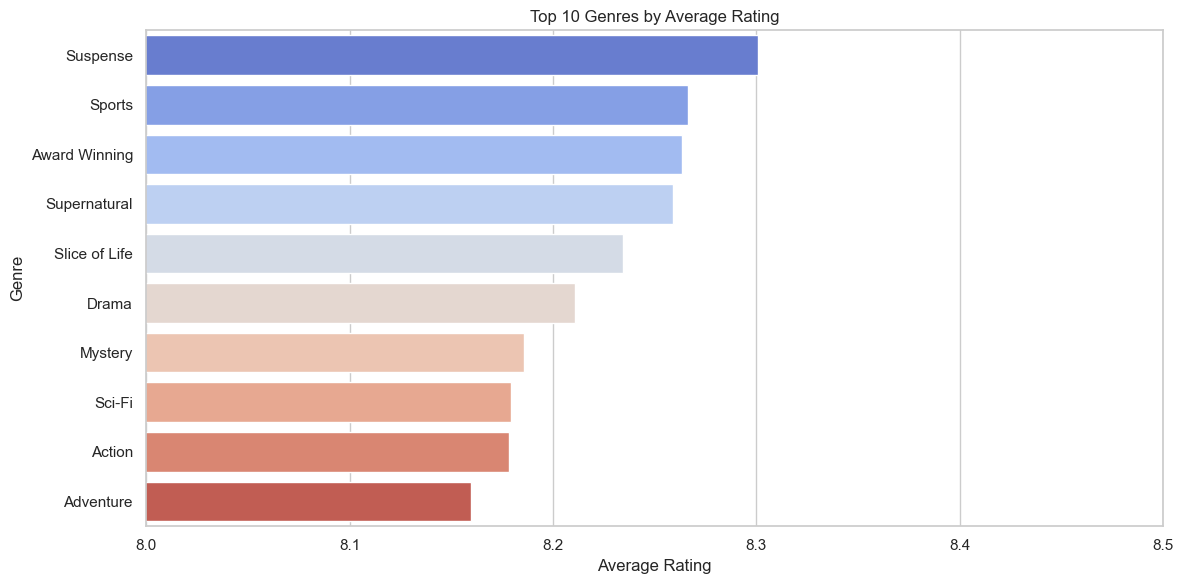

In [30]:
# Explode and calculate average rating per genre
genre_rating = df.explode('GenreList').groupby('GenreList')['Score'].mean().sort_values(ascending=False)

# Plot top 10 genres by average rating
plt.figure(figsize=(12,6))
sns.barplot(
    x=genre_rating.values[:10],
    y=genre_rating.index[:10],
    hue=genre_rating.index[:10],  # Assign y-axis (genre) to hue
    palette='coolwarm',
    legend=False                  # Hide the redundant legend
)

plt.title('Top 10 Genres by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.xlim(8, 8.5)  # 👈 Limit x-axis from 7 to 10
plt.tight_layout()
plt.savefig('../visuals/top_10_genres_by_rating.png')
plt.show()


# Visual 3 - Rating Distribution

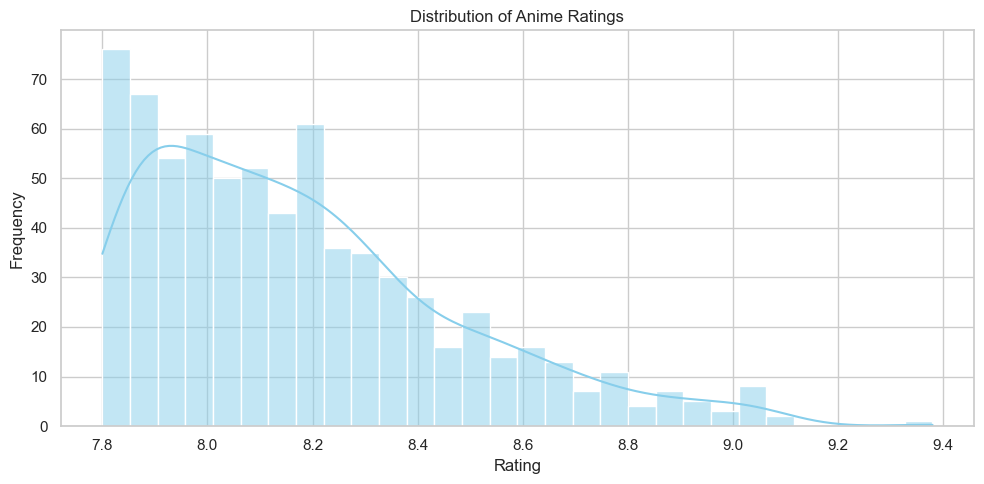

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(df['Score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Anime Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../visuals/rating_distribution.png')
plt.show()